# Análise dataset tabela fipe

## Fonte

[tabela-fipe kaggle](https://www.kaggle.com/datasets/franckepeixoto/tabela-fipe?select=tabela-fipe-historico-precos.csv)

In [18]:
############ Imports ############
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
df = pd.read_csv('data/tabela-fipe-historico-precos.csv')

# Remove the first column (index) if it exists
if df.columns[0] == 'Unnamed: 0':
    df = df.drop(columns=df.columns[0])

# Display the first few rows of the DataFrame
df.head()

,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
0,038003-2,Acura,Integra GS 1.8,1992,11,2016,13041.0
1,038001-6,Acura,NSX 3.0,1995,3,2013,52339.0
2,038003-2,Acura,Integra GS 1.8,1992,3,2018,12423.0
3,038002-4,Acura,Legend 3.2/3.5,1998,5,2016,31067.0
4,038002-4,Acura,Legend 3.2/3.5,1998,2,2019,26381.0


# Análise descritiva

* Distribuição dos preços.
* Evolução temporal dos valores médios por marca.
* Correlações

In [20]:
# Decribe the DataFrame to get summary statistics
df.describe()

,anoModelo,mesReferencia,anoReferencia,valor
count,466020.000000,466020.000000,466020.000000,4.660200e+05
mean,2008.968325,6.453541,2015.181181,1.157456e+05
std,9.999445,3.417056,5.677257,3.250737e+05
min,1985.000000,1.000000,2001.000000,1.871000e+03
25%,2000.000000,4.000000,2011.000000,1.938800e+04
50%,2009.000000,6.000000,2017.000000,3.941650e+04
75%,2020.000000,9.000000,2020.000000,8.479450e+04
max,2023.000000,12.000000,2022.000000,8.407082e+06


In [21]:
# The dataset does not have any missing values
df.isnull().sum()

# Now calculate the price variation over the years for each car model using pct_change
df = df.sort_values(['modelo', 'anoReferencia', 'mesReferencia'])
df['price_variation'] = df.groupby('modelo')['valor'].pct_change().mul(100)

In [ ]:
# Before plotting stuff, some models are the same with the same anoModelo, but different depending on the anoReferencia. The idea here is to exclude
# models that are the same, but keeping the most recent price based on the anoReferencia. This way we can get a better understanding of the relationship between price and other variables.

# First, create a date column by combining anoModelo and anoReferencia
df['date'] = pd.to_datetime(
    df['anoReferencia'].astype(str) + '-' + df['mesReferencia'].astype(str) + '-01'
)
df_original = df.copy()  # Keep a copy of the DataFrame after removing duplicates for reference

# Also, add the age of the vehicle based on the anoModelo - the current year (2026)
df['idade'] = df['anoReferencia'] - df['anoModelo']

# After analyzing the values, cars that have a valor bigger than 700.000,00 are outliers and would impact deeply
# not just the analysis, plots and scaling, afecting the model training itself, so for now, let's just exclude them from the dataset, but we can analyze them later on.
# These values represents only 248 models which are 5% of the dataset, so we are not losing much information by excluding them, but we are gaining a lot in terms of analysis and model performance.
# df = df[df['valor'] <= 600000]
# By forcing the value, the model will not be able to predict values higher than 600.000,00, but we can analyze these outliers later on and see if we can find a way to include them in the model training without impacting the performance too much.

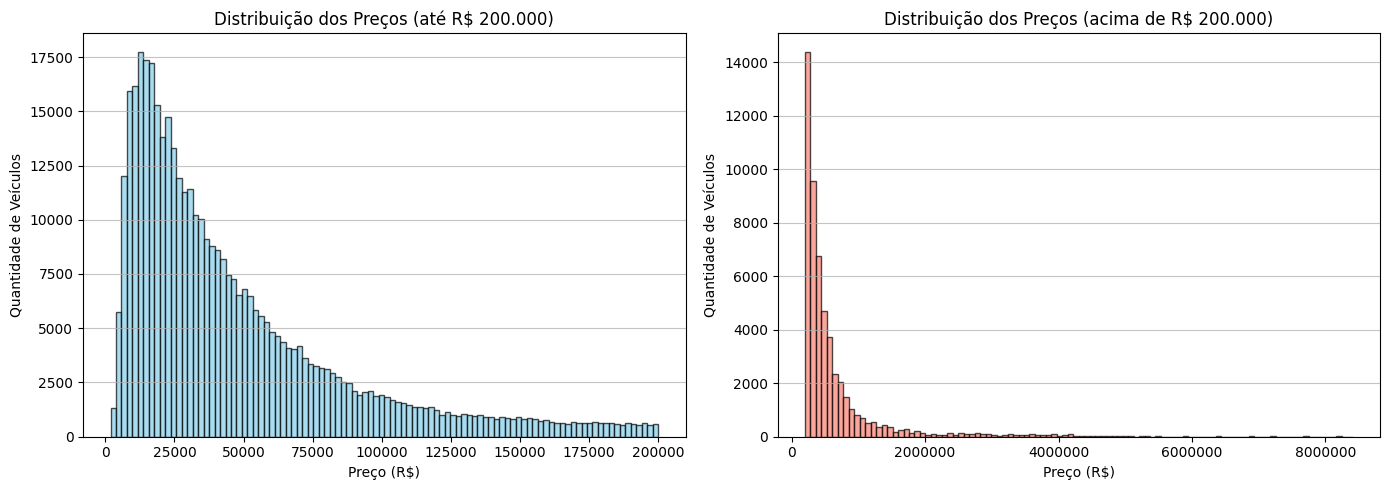

Total de veículos: 466020
Veículos com preço até R$ 200.000: 412421
Veículos com preço acima de R$ 200.000: 53599


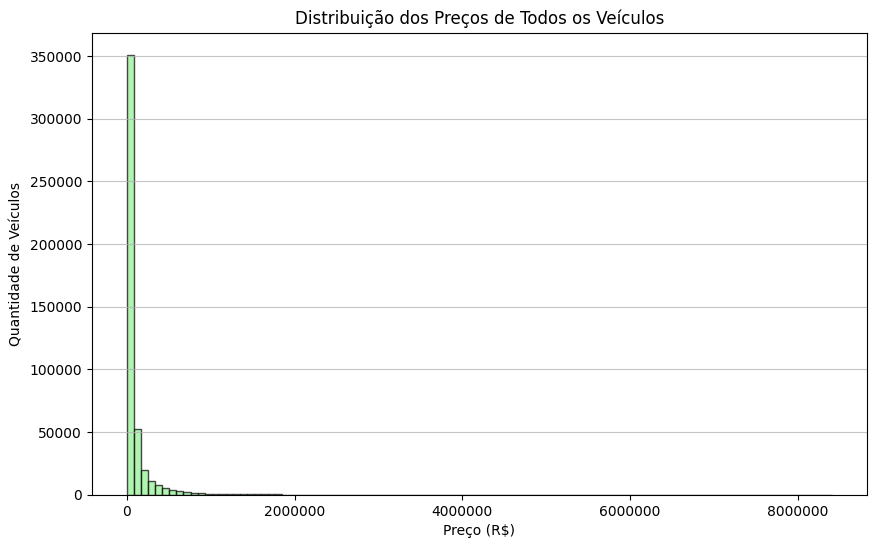

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# # It's hard to see the distribution of prices due to the presence of outliers. Let's zoom in on the prices up to R$ 200,000.
ax1.hist(df[df['valor'] < 200000]['valor'], bins=100,
         color='skyblue', edgecolor='black', alpha=0.7)

ax1.ticklabel_format(style='plain', axis='x')
ax1.set_title('Distribuição dos Preços (até R$ 200.000)')
ax1.set_xlabel('Preço (R$)')
ax1.set_ylabel('Quantidade de Veículos')
ax1.grid(axis='y', alpha=0.75)


# There are 60000 vehicles with prices up to R$ 200,000, and the distribution is right-skewed, with most vehicles priced below R$ 50,000. There are a few outliers with prices above R$ 200,000, which may represent luxury or rare vehicles.
# Let's also look at the distribution of prices for vehicles priced above R$ 200,000 to understand the outliers better.
ax2.hist(df[df['valor'] >= 200000]['valor'], bins=100,
         color='salmon', edgecolor='black', alpha=0.7)

ax2.ticklabel_format(style='plain', axis='x')
ax2.set_title('Distribuição dos Preços (acima de R$ 200.000)')
ax2.set_xlabel('Preço (R$)')
ax2.set_ylabel('Quantidade de Veículos')
ax2.grid(axis='y', alpha=0.75)


plt.tight_layout()
plt.show()

print(f"Total de veículos: {len(df)}")
print(f"Veículos com preço até R$ 200.000: {len(df[df['valor'] < 200000])}")
print(f"Veículos com preço acima de R$ 200.000: {len(df [df['valor'] >= 200000])}")

# Finally a plot with all the cars
plt.figure(figsize=(10, 6))
plt.hist(df['valor'], bins=100, color='lightgreen', edgecolor='black', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x')
plt.title('Distribuição dos Preços de Todos os Veículos')
plt.xlabel('Preço (R$)')
plt.ylabel('Quantidade de Veículos')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [24]:
# Since the prices are right-skewed, we can also look at the median price to get a better sense of the central tendency.
median_price = df['valor'].median()
print(f"Preço médio: R$ {df['valor'].mean():,.2f}")
print(f"Preço mediano: R$ {median_price:,.2f}")
print(f"Desvio padrão: R$ {df['valor'].std():,.2f}")

# Price and correlation with other variables
#correlation_matrix = df.corr()
corr = df.corr(numeric_only=True)
print('Correlação entre preço e outras variáveis:')
print(corr['valor'].sort_values(ascending=False))


Preço médio: R$ 115,745.60
Preço mediano: R$ 39,416.50
Desvio padrão: R$ 325,073.71
Correlação entre preço e outras variáveis:
valor              1.000000
anoModelo          0.261765
anoReferencia      0.077730
price_variation    0.027524
mesReferencia     -0.001696
idade             -0.201147
Name: valor, dtype: float64


In [25]:
# First some engineering on marca and modelo, the idea is to get the mean of the price for each marca and modelo, and then use that as a feature for the model. This way we can capture the effect of the brand and model on the price without having to deal with a large number of categorical variables.


# In order to avoid data leakage, we will calculate the mean price for each marca and modelo using only the training data, and then map those values to the entire dataset. This way we ensure that the mean price for each marca and modelo is calculated without using information from the test set.
from sklearn.model_selection import train_test_split

X = df.drop(columns=['valor', 'codigoFipe', 'date'])
y = df['valor']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop anoReferencia and mesReferencia since we already have the date column and the age of the vehicle, which are more informative than the anoReferencia and mesReferencia columns. Also, dropping them will help to reduce the dimensionality of the dataset and avoid multicollinearity issues.
X_train = X_train.drop(columns=['anoReferencia', 'mesReferencia'])
X_test = X_test.drop(columns=['anoReferencia', 'mesReferencia'])

marca_mean = X_train.join(y_train).groupby('marca')['valor'].mean()
modelo_mean = X_train.join(y_train).groupby('modelo')['valor'].mean()

X_train['marca_mean_price'] = X_train['marca'].map(marca_mean)
X_test['marca_mean_price'] = X_test['marca'].map(marca_mean)

X_train['modelo_mean_price'] = X_train['modelo'].map(modelo_mean)
X_test['modelo_mean_price'] = X_test['modelo'].map(modelo_mean)

global_mean = y_train.mean()

X_train['marca_mean_price'] = X_train['marca_mean_price'].fillna(global_mean)
X_test['marca_mean_price'] = X_test['marca_mean_price'].fillna(global_mean)

X_train['modelo_mean_price'] = X_train['modelo_mean_price'].fillna(global_mean)
X_test['modelo_mean_price'] = X_test['modelo_mean_price'].fillna(global_mean)

X_train.drop(columns=['marca', 'modelo'], inplace=True)
X_test.drop(columns=['marca', 'modelo'], inplace=True)

X_train['price_variation'] = X_train['price_variation'].fillna(0)
X_test['price_variation'] = X_test['price_variation'].fillna(0)

print(X_train.isna().sum().sort_values(ascending=False).head(10))
print(X_test.isna().sum().sort_values(ascending=False).head(10))


anoModelo            0
price_variation      0
idade                0
marca_mean_price     0
modelo_mean_price    0
dtype: int64
anoModelo            0
price_variation      0
idade                0
marca_mean_price     0
modelo_mean_price    0
dtype: int64


In [28]:
# Now let's train and compare 5 regression algorithms: Linear Regression, Ridge Regression, Random Forest Regressor, Gradient Boosting Regressor and SVR.
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

##### all the models bellow were used to train the data, and the random forest regressor were the best:
##### {'Random Forest Regressor': {'MAE': 8711.538361734953, 'RMSE': 23408.63734216152, 'R2': 0.9948091455843121}
models = {
    # 'Linear Regression': LinearRegression(),
    # 'Ridge Regression': Ridge(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=50, max_depth=12, min_samples_split=10, n_jobs=-1, random_state=42),
    # 'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42),
    'Hist Gradient Boosting Regressor': HistGradientBoostingRegressor(max_iter=100, max_depth=10)
}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        mae_scores.append(mean_absolute_error(y_val, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        r2_scores.append(r2_score(y_val, y_pred))
        
    results[name] = {
        'MAE': np.mean(mae_scores),
        'RMSE': np.mean(rmse_scores),
        'R2': np.mean(r2_scores)
    }

# Display the results
print(results)
y_test.mean()


Training Random Forest Regressor...

Training Hist Gradient Boosting Regressor...
{'Random Forest Regressor': {'MAE': 8711.538361734953, 'RMSE': 23408.63734216152, 'R2': 0.9948091455843121}, 'Hist Gradient Boosting Regressor': {'MAE': 14040.249703606314, 'RMSE': 65509.28604423448, 'R2': 0.9593516995145481}}


116192.25645895026

In [27]:
# Exporting the best model
import joblib
from sklearn.pipeline import Pipeline

df = pd.read_csv("data/tabela-fipe-historico-precos.csv")

marca_mean = df.groupby("marca")["valor"].mean().to_dict()
modelo_mean = df.groupby("modelo")["valor"].mean().to_dict()
global_mean = df["valor"].mean()

pipeline = Pipeline([
    ('model',  RandomForestRegressor(n_estimators=50, max_depth=12, min_samples_split=10, n_jobs=-1, random_state=42))
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, 'model.pkl')


['model.pkl']